## Importação de Bibliotecas 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Configuração de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Carregamento e Limpeza do Dados

In [ ]:
df = pd.read_csv('GlobalFireBurnedArea_2022.csv')

# Converter colunas de data para o formato datetime do pandas
df['Initialdate'] = pd.to_datetime(df['Initialdate'])
df['Finaldate'] = pd.to_datetime(df['Finaldate'])

# Extrair o Mês (1 a 12) da data inicial para a análise temporal
df['Month'] = df['Initialdate'].dt.month

# Calcular a Duração em dias (Final - Inicial)
df['duracao_dias'] = (df['Finaldate'] - df['Initialdate']).dt.days
#df = df[df['Duraton_days'] >= 0]

# Remocão de dados inválidos
df = df.dropna(subset=['Initialdate', 'Finaldate', 'Area_ha'])
df = df[df['Area_ha'] > 0] 

# Criacão de atributos temporais
df['mes_inicio'] = df['Initialdate'].dt.month
df['dia_ano'] = df['Initialdate'].dt.dayofyear
df['trimestre'] = df['Initialdate'].dt.quarter

# Remoção de Outliers
Q1 = df['Area_ha'].quantile(0.025)
Q3 = df['Area_ha'].quantile(0.975)
df = df[(df['Area_ha'] >= Q1) & (df['Area_ha'] <= Q3)]

# Limpeza básica
df = df[df['duracao_dias'] >= 0].copy()
df = df.drop(columns=['ID', 'Area_m2', 'Area_Km2'], errors='ignore')

display(df[['Initialdate', 'mes_inicio', 'dia_ano', 'trimestre', 'duracao_dias', 'Area_ha']].head())
print("Dimensões do Dataset após limpeza:", df.shape)
df.head()

,Initialdate,mes_inicio,dia_ano,trimestre,duracao_dias,Area_ha
11,2022-02-08,2,39,1,0,128.633563
69,2022-06-15,6,166,2,0,106.925499
80,2022-07-16,7,197,3,0,128.246379
82,2022-07-20,7,201,3,0,128.311300
88,2022-08-02,8,214,3,0,128.322808


Dimensões do Dataset após limpeza: (303314, 11)


,Initialdate,Finaldate,Area_ha,CountryName,Continent,Region,Month,duracao_dias,mes_inicio,dia_ano,trimestre
11,2022-02-08,2022-02-08,128.633563,Argentina,Americas,South America,2,0,2,39,1
69,2022-06-15,2022-06-15,106.925499,Australia,Oceania,Australia and New Zealand,6,0,6,166,2
80,2022-07-16,2022-07-16,128.246379,Democratic Republic of the Congo,Africa,Middle Africa,7,0,7,197,3
82,2022-07-20,2022-07-20,128.311300,Zambia,Africa,Eastern Africa,7,0,7,201,3
88,2022-08-02,2022-08-02,128.322808,Zambia,Africa,Eastern Africa,8,0,8,214,3


## Análise Exploratória Temporal

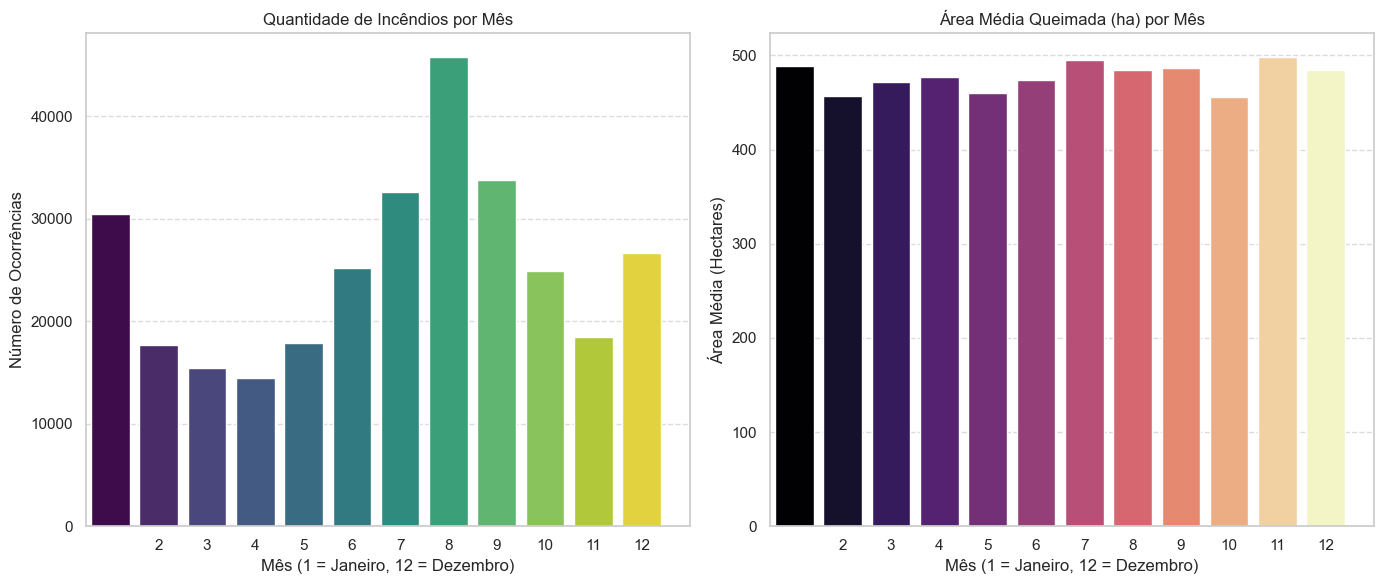

In [ ]:
plt.figure(figsize=(14, 6))

# Gráfico 1: Em quais meses acontecem MAIS incêndios (Quantidade)
plt.subplot(1, 2, 1)
fires_per_month = df['Month'].value_counts().sort_index()
sns.barplot(x=fires_per_month.index, y=fires_per_month.values, hue=fires_per_month.index, palette='viridis', legend=False)
plt.title('Quantidade de Incêndios por Mês')
plt.xlabel('Mês (1 = Janeiro, 12 = Dezembro)')
plt.ylabel('Número de Ocorrências')
plt.xticks(range(1, 13))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Gráfico 2: Em quais meses ocorrem os MAIORES incêndios (Área Média em Hectares)
plt.subplot(1, 2, 2)
area_per_month = df.groupby('Month')['Area_ha'].mean()
sns.barplot(x=area_per_month.index, y=area_per_month.values, hue=area_per_month.index, palette='magma', legend=False)
plt.title('Área Média Queimada (ha) por Mês')
plt.xlabel('Mês (1 = Janeiro, 12 = Dezembro)')
plt.ylabel('Área Média (Hectares)')
plt.xticks(range(1, 13))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Pré-processamento dos Dados para Machine Learning

In [ ]:
# 1. Selecionar features e target
features = ['mes_inicio', 'dia_ano', 'trimestre', 'Continent', 'Region', 'duracao_dias']

# 2. Criar dataframe com as colunas de interesse
df_ml = df[features + ['Area_ha']].copy()

# 3. One-Hot Encoding nas variáveis categóricas (Continent, Region)
df_ml_encoded = pd.get_dummies(df_ml, columns=['Continent', 'Region'], drop_first=True)

# 4. Transformação logarítmica no alvo para lidar com outliers globais
df_ml_encoded['Area_ha_log'] = np.log1p(df_ml_encoded['Area_ha'])

# 5. Definir X (features) e y (target logarítmico)
X = df_ml_encoded.drop(columns=['Area_ha', 'Area_ha_log'])
y = df_ml_encoded['Area_ha_log']

# 6. Divisão em dados de Treino (70%) e Teste (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Dados preparados. Shape de X_train: {X_train.shape}")
print(f"Shape de X_test: {X_test.shape}")

Dados preparados. Shape de X_train: (212319, 27)
Shape de X_test: (90995, 27)


## Treinamento do Modelo

Treinando o modelo Gradient Boosting...

--- Métricas de Avaliação (Escala Logarítmica) ---
R² (Coeficiente de Determinação): 0.3925
MAE (Erro Absoluto Médio Log): 0.5258
MAE (Erro Absoluto Médio em Hectares Reais): 258.01 ha


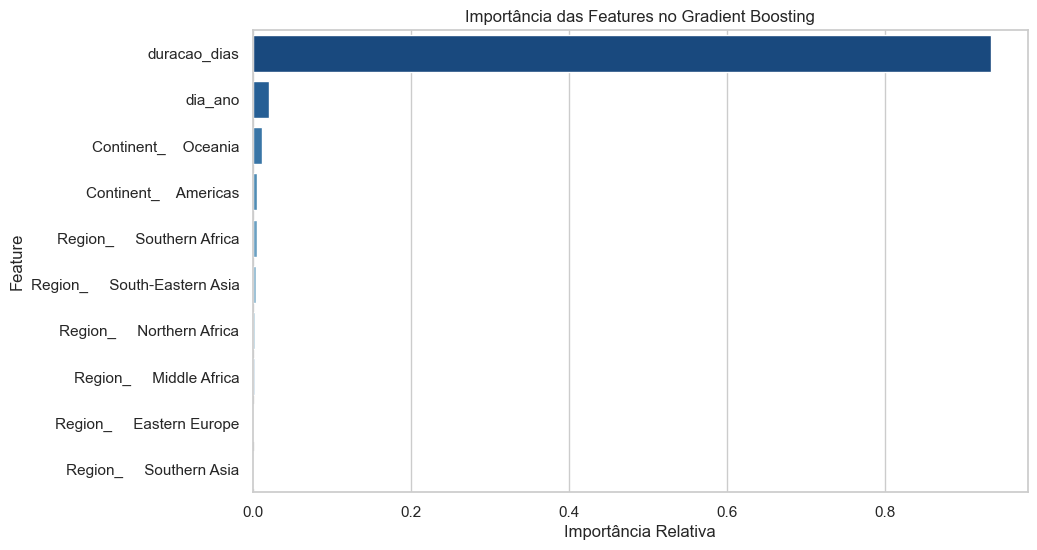

In [7]:
# 1. Instanciar o Gradient Boosting Regressor
modelo_gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)

# 2. Treinar o modelo
print("Treinando o modelo Gradient Boosting...")
modelo_gb.fit(X_train, y_train)

# 3. Fazer previsões (o modelo prevê na escala logarítmica)
y_pred_log = modelo_gb.predict(X_test)

# 4. Avaliar o modelo na escala logarítmica (mais estável e justa para o R²)
r2 = r2_score(y_test, y_pred_log)
mae_log = mean_absolute_error(y_test, y_pred_log)

print("\n--- Métricas de Avaliação (Escala Logarítmica) ---")
print(f"R² (Coeficiente de Determinação): {r2:.4f}")
print(f"MAE (Erro Absoluto Médio Log): {mae_log:.4f}")

# 5. Converter previsões de volta para hectares para interpretação humana
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)
mae_real = mean_absolute_error(y_test_real, y_pred_real)
print(f"MAE (Erro Absoluto Médio em Hectares Reais): {mae_real:,.2f} ha")

# 6. Importância das Features
importancias = modelo_gb.feature_importances_
df_importancia = pd.DataFrame({'Feature': X.columns, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_importancia, x='Importancia', y='Feature', hue='Feature', palette='Blues_r', legend=False)
plt.title('Importância das Features no Gradient Boosting')
plt.xlabel('Importância Relativa')
plt.show()

## Visualização: Dados Reais X Previstos

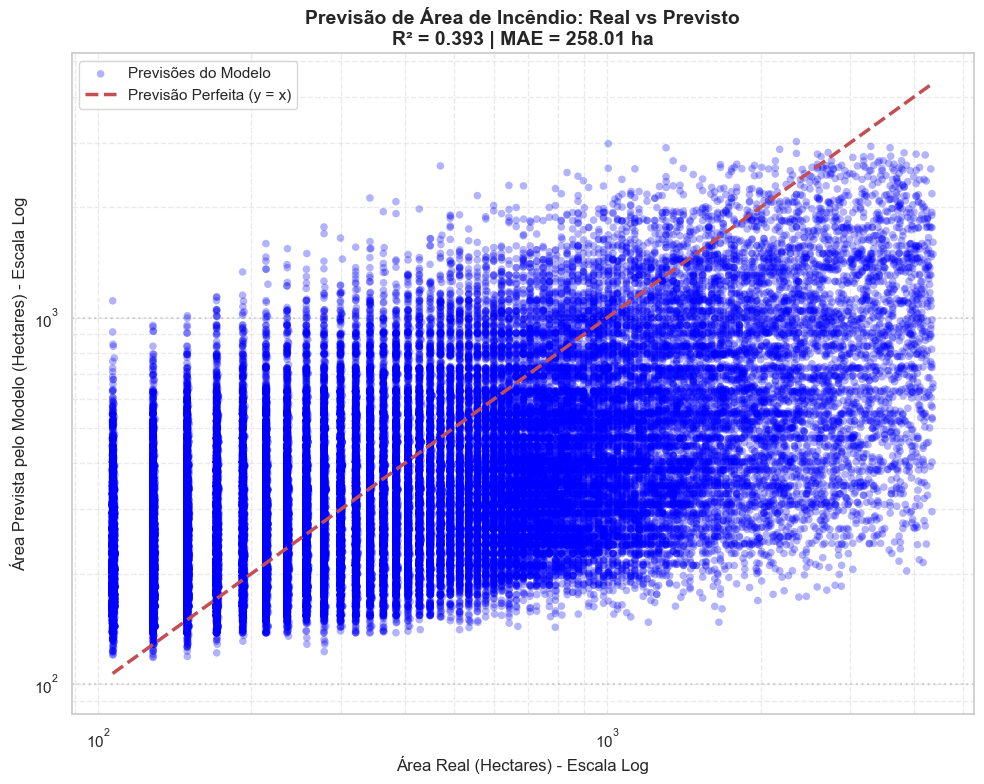

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot dos pontos
ax.scatter(y_test_real, y_pred_real, alpha=0.3, color='blue', 
           edgecolor='none', s=30, label='Previsões do Modelo')

# Linha de previsão perfeita (y = x)
min_val = min(y_test_real.min(), y_pred_real.min())
max_val = max(y_test_real.max(), y_pred_real.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2.5, 
        label='Previsão Perfeita (y = x)', zorder=5)

# Linhas de referência para ajudar na leitura
# Mostra regiões de "subestimação" e "superestimação"
ax.axhline(y=100, color='gray', linestyle=':', alpha=0.3)
ax.axhline(y=1000, color='gray', linestyle=':', alpha=0.3)

# Escala logarítmica em ambos os eixos
ax.set_xscale('log')
ax.set_yscale('log')

# Labels e título informativos
ax.set_xlabel('Área Real (Hectares) - Escala Log', fontsize=12)
ax.set_ylabel('Área Prevista pelo Modelo (Hectares) - Escala Log', fontsize=12)
ax.set_title(f'Previsão de Área de Incêndio: Real vs Previsto\n'
             f'R² = {r2:.3f} | MAE = {mae_real:,.2f} ha', 
             fontsize=14, fontweight='bold')

ax.legend(loc='upper left', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4, which='both')

plt.tight_layout()
plt.show()

# BÔNUS: Adicione esta análise textual logo abaixo do gráfico no seu notebook
#print("\n📌 INTERPRETAÇÃO DO GRÁFICO:")
#print("- Pontos AO LONGO da linha vermelha tracejada = previsões precisas.")
#print("- Pontos ACIMA da linha = o modelo SUPERESTIMOU a área.")
#print("- Pontos ABAIXO da linha = o modelo SUBESTIMOU a área.")
#print(f"- A dispersão ao redor da diagonal indica que o modelo está aprendendo")
#print(f"  padrões, mas ainda há incerteza inerente ao problema (R² = {r2:.3f}).")